In [17]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torch.nn as nn
from torchvision.models import efficientnet_b0
import torchaudio
import torchaudio.transforms as T
import pandas as pd
import soundfile as sf
import math
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from datetime import datetime

In [2]:
print (torch.cuda.is_available())
print(torch.cuda.get_device_properties())
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB')
print(f'CUDA Version: {torch.version.cuda}')

True
_CudaDeviceProperties(name='NVIDIA GeForce RTX 2060', major=7, minor=5, total_memory=6143MB, multi_processor_count=30, uuid=6e79eb6f-09fa-1fe4-df0e-cc6342c1db19, L2_cache_size=3MB)
VRAM: 6.00 GB
CUDA Version: 12.4


In [3]:
files = Path('../data/train_audio').rglob('*.ogg')
print(f'number of files in train_audio folder: {len(list(files))}')
import pandas as pd
train_df = pd.read_csv('../data/train.csv')
print(f'number of data rows in train.csv: {len(train_df)}')



number of files in train_audio folder: 35549
number of data rows in train.csv: 35549


In [4]:

train_df.head(10)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat
5,1161364,[],[],-22.0843,-47.7327,Guyalna cuta,Guyalna cuta,Insecta,1161364,Carlos Otávio Gussoni,cc-by-nc,0.0,https://static.inaturalist.org/sounds/868369.w...,1161364/iNat868369.ogg,iNat
6,1161364,[],[],-20.9848,-43.7609,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/842139.w...,1161364/iNat842139.ogg,iNat
7,1161364,[],[],-19.9674,-43.9895,Guyalna cuta,Guyalna cuta,Insecta,1161364,Pedro Cavalcante,cc-by-nc,0.0,https://static.inaturalist.org/sounds/840159.m...,1161364/iNat840159.ogg,iNat
8,1161364,[],[],-19.8713,-43.9607,Guyalna cuta,Guyalna cuta,Insecta,1161364,Alexandre S. Michelotto,cc0,0.0,https://static.inaturalist.org/sounds/1264238....,1161364/iNat1264238.ogg,iNat
9,1161364,[],[],-18.8358,-40.7354,Guyalna cuta,Guyalna cuta,Insecta,1161364,Vitor C. Dias Gonçalves,cc-by-nc,0.0,https://static.inaturalist.org/sounds/869958.m...,1161364/iNat869958.ogg,iNat


### Check that files in subfolders are the same as the entries in train.csv


In [5]:
folders = [f for f in Path('../data/train_audio').iterdir() if f.is_dir()]
print(f'number of folders in train_audio: {len(folders)}')
for folder in folders:
    files_in_folder = [str(f.relative_to('../data/train_audio/')) for f in folder.rglob('*.ogg')]
    sub_df = train_df[train_df['primary_label']== folder.name]['filename']
    files_set = set(files_in_folder)
    sub_df_set = set(sub_df)
    missing_in_folder = sub_df_set - files_set
    missing_in_csv = files_set - sub_df_set
    if (len(missing_in_csv)!=0) or (len(missing_in_csv)!=0): 
        print(f'{folder}: In df but not in folder: ', missing_in_folder)
        print(f'{folder}: In folder but not in df: ', missing_in_csv)

number of folders in train_audio: 206


### Chunking the long files


### Inserted_df in vectorized way

In [6]:
train_df = train_df[['primary_label', 'filename']]
train_df['file_path'] = '../data/train_audio/' + train_df['filename']
FIXED_LENGTH = 5 # the duration of a standard audio in seconds
def get_chunks_number(file_path:str):
    '''
    returns the number of chunks
    for the file in row idx of train_df
    '''
    return math.ceil(sf.info(file_path).duration/FIXED_LENGTH)
new_idx = train_df.index.repeat(train_df['file_path'].apply(get_chunks_number))
train_df = train_df.loc[new_idx].reset_index(drop=True)
train_df['offset_sec'] = train_df.groupby('file_path').cumcount()*FIXED_LENGTH
train_df.head(30) 


,primary_label,filename,file_path,offset_sec
0,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,0
1,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,5
2,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,10
3,1161364,1161364/iNat1216197.ogg,../data/train_audio/1161364/iNat1216197.ogg,15
4,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,0
5,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,5
6,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,10
7,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,15
8,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,20
9,1161364,1161364/iNat1114648.ogg,../data/train_audio/1161364/iNat1114648.ogg,25


In [7]:
labels = sorted(train_df['primary_label'].unique()) 
label2idx = {label:idx for idx, label in enumerate(labels)}
train_df['encoded_label'] = train_df['primary_label'].map(label2idx)
SAMPLE_RATE = sf.info(train_df['file_path'][0]).samplerate
N_FFT = 1024
HOP_LENGTH = 512
F_MIN = 500
F_MAX = 16000
N_MELS = 128
WINDOW_FUNCTION = torch.hamming_window
TARGET_LENGTH = FIXED_LENGTH * SAMPLE_RATE
NUM_CLASSES = len(labels)

transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    f_min=F_MIN,
    f_max=F_MAX,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    window_fn=WINDOW_FUNCTION
)
class BirdSoundDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.to_db = T.AmplitudeToDB()
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = row['file_path']
        waveform, _ = torchaudio.load(
            file_path,
            frame_offset=int(row['offset_sec']) * SAMPLE_RATE,
            num_frames=TARGET_LENGTH
            )
        if waveform.shape[0] > 1:                          # stereo → mono, safe-guarding in case there are 2 channels
            waveform = waveform.mean(dim=0, keepdim=True)
        if waveform.shape[1] < TARGET_LENGTH:
            padding = TARGET_LENGTH - waveform.shape[1]
            waveform = nn.functional.pad(waveform, (0, padding))
        if self.transform:
            waveform = self.transform(waveform)
        waveform = self.to_db(waveform)
        
        waveform = waveform.repeat(3,1,1) # -> (3, 128, time) to be able to fit into the efficient_net0
        return waveform, torch.tensor(row['encoded_label'],dtype=torch.long)
    
bird_dataset = BirdSoundDataset(train_df, transform)


In [8]:
waveform, label = bird_dataset[0]
print(waveform.shape)
print(label)

torch.Size([3, 128, 313])
tensor(0)


### Training the EfficientNet_b0 model on the melspectrograms

In [ ]:

reduced_dataset = Subset(bird_dataset, range(1000))
def train_model(model, model_name, dataset, num_epochs):
    train_dataset, val_dataset, test_dataset = random_split(dataset, [0.8, 0.1, 0.1])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)    
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    avg_val_losses = []
    best_avg_val_loss = float('inf')
    for epoch in range(num_epochs):
        # training the model
        model.train()
        for mels, labels in tqdm(train_loader,desc=f'Epoch {epoch} [train]'):
            mels, labels = mels.to(device), labels.to(device)
            preds = model(mels)
            loss = criterion(preds, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # evaluating the model
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for mels, labels in tqdm(val_loader, desc=f'Epoch {epoch} [val]'):
                mels, labels = mels.to(device), labels.to(device)
                preds = model(mels)
                val_loss += criterion(preds, labels).item()
        avg_val_loss = val_loss/len(val_loader)
        avg_val_losses.append(avg_val_loss)
        if avg_val_loss < best_avg_val_loss:
            best_avg_val_loss = avg_val_loss
            save_file_path = '../models/' + model_name + '_best_' +\
                  datetime.now().strftime("%Y%m%d")+'.pth'
            torch.save(model.state_dict(), save_file_path)
            
        print(f'Epoch: {epoch} average loss on evaluation dataset: {avg_val_loss}')
    loss_per_epoch = [range(1, num_epochs+1), avg_val_losses]
    csv_save_file_path = '../models/' + model_name + '_' +\
                        datetime.now().strftime("%Y%m%d")+'.csv'
    pd.DataFrame(loss_per_epoch).to_csv(csv_save_file_path, index=False)

    fig = plt.figure(figsize=(6,10))
    plt.plot(range(1, num_epochs+1), avg_val_losses)
    plt.title('Loss vs Epoch')
    plt.show()
    return test_loader






NameError: name 'loss_per_epoch' is not defined

Epoch 0 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

Epoch 0 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch: 0 average loss on evaluation dataset: 1.5284682059689694


Epoch 1 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

Epoch 1 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

...

Epoch 3 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch: 3 average loss on evaluation dataset: 0.9583800439818098


Epoch 4 [train]:   0%|          | 0/6649 [00:00<?, ?it/s]

Epoch 4 [val]:   0%|          | 0/831 [00:00<?, ?it/s]

Epoch: 4 average loss on evaluation dataset: 0.8922835327102102


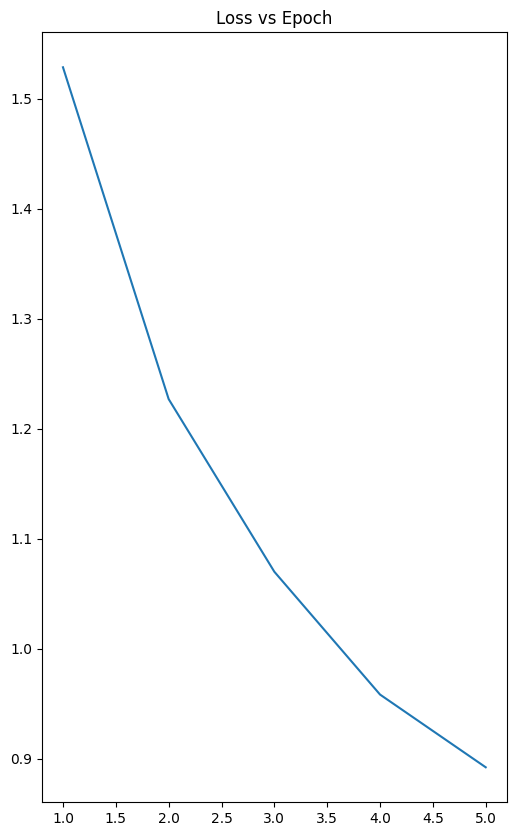

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.to(device)
test_loader = train_model(model, 'efficientnet_b0', bird_dataset, 5)

In [10]:
torch.save(model.state_dict(), '../models/efficientnet_b0_birdclef_260414.pth')

In [34]:
def evaluate_model(model) -> float:
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for mels, labels in tqdm(test_loader, desc=f'Evaluating the model ...'):
            mels, labels = mels.to(device), labels.to(device)
            preds = model(mels)
            eval_loss += criterion(preds, labels).item()

    print(f'Average Loss on the test datase: {eval_loss/len(test_loader)}')
    return eval_loss/len(test_loader)

In [35]:
original_model = efficientnet_b0(weights='IMAGENET1K_V1')
original_model.classifier[1] = nn.Linear(original_model.classifier[1].in_features, NUM_CLASSES)
original_model.to(device)
evaluate_model(original_model)

Evaluating the model ...:   0%|          | 0/831 [00:00<?, ?it/s]

Average Loss on the test datase: 156.0937456895298


156.0937456895298

In [ ]:
reload_model = efficientnet_b0(weights = None)
reload_model.classifier[1] = nn.Linear(reload_model.classifier[1].in_features, NUM_CLASSES)
reload_model.load_state_dict(torch.load('../models/efficientnet_b0_20260415.pth')) # after 5 epoch training
reload_model.to(device)
evaluate_model(reload_model)

Evaluating the model ...:   0%|          | 0/831 [00:00<?, ?it/s]

Average Loss on the test datase: 0.9232952530741261


767.2583553045988

In [ ]:
# And to load it back:
model = efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(1280, NUM_CLASSES)
model.load_state_dict(torch.load('efficientnet_b0_birdclef.pth'))
model.to(device)
model.eval()


In [ ]:
Save inside the training loop to keep the best model (lowest val loss):


best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # ... training ...
    # ... validation ...

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  → saved best model (val loss: {best_val_loss:.4f})')

In [ ]:
print (torch.cuda.is_available())

True


In [ ]:
a=[0,1,2,3]
a[1:1+1]

## For references

In [15]:
# Code and resutt when evaluate_model hasn't been implemented avarage loss
original_model = efficientnet_b0(weights='IMAGENET1K_V1')
original_model.classifier[1] = nn.Linear(original_model.classifier[1].in_features, NUM_CLASSES)
original_model.to(device)
evaluate_model(original_model)

Evaluating the model ...:   0%|          | 0/831 [00:00<?, ?it/s]

Loss on the test datase: 124277.34286880493


124277.34286880493

In [ ]:
# result after 1 epoch training, loss has not been averaged yet.
evaluate_model(model)

Evaluating the model ...:   0%|          | 0/831 [00:00<?, ?it/s]

Loss on the test datase: 1290.8003017306328


1290.8003017306328

In [ ]:
reduced_df = train_df[['primary_label']].copy()
reduced_df['file_path'] = train_df.apply(lambda row: f"../data/train_audio/{row['filename']}", axis=1)
reduced_df['offset_sec'] = 0
reduced_df.head(30)

In [ ]:
FIXED_LENGTH = 5 # seconds
inserted_df = pd.DataFrame(columns = ['primary_label', 'file_path', 'offset_sec'])
for i in range(len(train_df)):
    file_path = '../data/train_audio/'+ train_df['filename'][i]
    primary_label = train_df['primary_label'][i]
    info = sf.info(file_path)
    if (info.duration % FIXED_LENGTH != 0):
        for j in range(int(info.duration/FIXED_LENGTH)+1):
            new_row = pd.DataFrame([{'primary_label': primary_label, 
                       'file_path': file_path, 
                       'offset_sec': j*FIXED_LENGTH}])
            inserted_df = pd.concat([inserted_df, new_row], ignore_index=True)
    else:
        for j in range(int(info.duration/FIXED_LENGTH)):
            new_row = pd.DataFrame([{'primary_label': primary_label, 
                       'file_path': file_path, 
                       'offset_sec': j*FIXED_LENGTH}])
            inserted_df = pd.concat([inserted_df, new_row], ignore_index=True)
inserted_df.head(30)

In [ ]:
inserted_df.to_csv('../inserted_df.csv', index=False)

### Practicing repeat and cumcount

In [ ]:
some_df = pd.DataFrame({'col1': ['aaa','bb','c','dddd', 'abcd'], 'col2':[1, 1, 3, 3, 3]})
#print(f'{some_df.apply(lambda row: len(row['col1']), axis=1)}')
a = some_df.apply(lambda row: len(row['col1']), axis=1)
b = some_df.index.repeat(a)
expanded_df = some_df.loc[b].reset_index(drop=True)
expanded_df['off_set'] = expanded_df.groupby('col1').cumcount()*5
print(f'{a}')
print(f'{b}')
print (math.ceil(15.0/5))
expanded_df.head(20)
# some_df.index.repeat(some_df.apply(lambda row: len(row['col1']), axis=1))
# some_df.head(10)
#some_df.index.repeat(len(some_df['col1'].apply(lambda row: len(row))))

In [ ]:
train_df['file_path'] = '../data/train_audio/' + train_df['filename']
FIXED_LENGTH = 5
def get_chunks_number(file_path:str):
    '''
    returns the number of chunks
    for the file in row idx of train_df
    '''
    return math.ceil(sf.info(file_path).duration/FIXED_LENGTH)
new_idx = train_df.index.repeat(train_df['file_path'].apply(get_chunks_number))
train_df = train_df.loc[new_idx].reset_index(drop=True)
train_df['offset_sec'] = train_df.groupby('file_path').cumcount()*FIXED_LENGTH
train_df = train_df[['primary_label', 'file_path', 'offset_sec']]
train_df.head(30) 